# 06 Baseline D0: Global Paper-Share Baseline

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / '06_baseline_d0_global_paper_share'
FIGURE_DIR = NOTEBOOK_OUTPUT_DIR / 'figures'
TABLE_DIR = NOTEBOOK_OUTPUT_DIR / 'tables'
DATA_OUTPUT_DIR = NOTEBOOK_OUTPUT_DIR / 'data'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GENDER_CATEGORIES = ['MM', 'MW', 'WM', 'WW']
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
known_categories = ['MM', 'MW', 'WM', 'WW']

## 1. Load Data

In [3]:
papers = pd.read_pickle(PROCESSED_DIR / 'papers_final.pkl')
citation_edges_final = pd.read_pickle(PROCESSED_DIR / 'citation_edges_final.pkl')
citation_edges_all_to_cs = pd.read_pickle(PROCESSED_DIR / 'citation_edges_all_to_cs_final.pkl')
citation_edges_cs_to_cs = pd.read_pickle(PROCESSED_DIR / 'citation_edges_cs_to_cs_final.pkl')
papers['id'] = papers['id'].astype(str)

def standardize_edge_columns(edges):
    out = edges.rename(columns={'citing_paper_id': 'citing', 'cited_paper_id': 'cited'})[['citing', 'cited']].copy()
    out['citing'] = out['citing'].astype(str)
    out['cited'] = out['cited'].astype(str)
    return out
citation_edges_final = standardize_edge_columns(citation_edges_final)
citation_edges_all_to_cs = standardize_edge_columns(citation_edges_all_to_cs)
citation_edges_cs_to_cs = standardize_edge_columns(citation_edges_cs_to_cs)
out_degree_final = citation_edges_final.groupby('citing', sort=False).size()
in_degree_final = citation_edges_final.groupby('cited', sort=False).size()
papers['out_degree'] = papers['id'].map(out_degree_final).fillna(0).astype('int64')
papers['in_degree'] = papers['id'].map(in_degree_final).fillna(0).astype('int64')
print('Papers:', papers.shape)
print('Final citation edges:', citation_edges_final.shape)
print('All→CS citation edges:', citation_edges_all_to_cs.shape)
print('CS→CS citation edges:', citation_edges_cs_to_cs.shape)

Papers: (3026412, 31)
Final citation edges: (18904534, 2)
All→CS citation edges: (11601416, 2)
CS→CS citation edges: (9413932, 2)


## 2. Prepare Computer Science and Known-Gender Subsets

In [4]:
papers_cs = papers[papers['primary_field'] == 'Computer Science'].copy()
papers_cs_known = papers_cs[papers_cs['first_last_cat'].isin(known_categories)].copy()
cs_paper_ids = set(papers_cs['id'])
cs_known_paper_ids = set(papers_cs_known['id'])
cs_subset_summary = pd.Series({'n_all_papers': len(papers), 'n_cs_papers': len(papers_cs), 'cs_share_of_all_papers_pct': round(len(papers_cs) / len(papers) * 100, 2), 'n_cs_known_gender_papers': len(papers_cs_known), 'known_gender_share_among_cs_papers_pct': round(len(papers_cs_known) / len(papers_cs) * 100, 2)})
cs_subset_summary

n_all_papers                             3,026,412.0000
n_cs_papers                              1,542,691.0000
cs_share_of_all_papers_pct                      50.9700
n_cs_known_gender_papers                 1,081,363.0000
known_gender_share_among_cs_papers_pct          70.1000
dtype: float64

In [5]:
cited_gender_map = papers_cs.set_index('id')['first_last_cat']
edges_all_to_known_cs = citation_edges_all_to_cs[citation_edges_all_to_cs['cited'].isin(cs_known_paper_ids)].copy()
edges_cs_to_known_cs = citation_edges_cs_to_cs[citation_edges_cs_to_cs['cited'].isin(cs_known_paper_ids)].copy()
edges_all_to_known_cs['cited_first_last_cat'] = edges_all_to_known_cs['cited'].map(cited_gender_map)
edges_cs_to_known_cs['cited_first_last_cat'] = edges_cs_to_known_cs['cited'].map(cited_gender_map)
edge_slice_summary = pd.Series({'n_all_citation_edges': len(citation_edges_final), 'n_all_to_known_cs_edges': len(edges_all_to_known_cs), 'n_cs_to_known_cs_edges': len(edges_cs_to_known_cs), 'all_to_known_cs_share_of_all_edges_pct': round(len(edges_all_to_known_cs) / len(citation_edges_final) * 100, 2), 'cs_to_known_cs_share_of_all_to_known_cs_edges_pct': round(len(edges_cs_to_known_cs) / len(edges_all_to_known_cs) * 100, 2), 'n_unique_citing_papers_all_to_cs': edges_all_to_known_cs['citing'].nunique(), 'n_unique_citing_papers_cs_to_cs': edges_cs_to_known_cs['citing'].nunique(), 'n_unique_cited_known_cs_papers_all_to_cs': edges_all_to_known_cs['cited'].nunique(), 'n_unique_cited_known_cs_papers_cs_to_cs': edges_cs_to_known_cs['cited'].nunique()})
edge_slice_summary

n_all_citation_edges                                18,904,534.0000
n_all_to_known_cs_edges                              8,686,237.0000
n_cs_to_known_cs_edges                               7,023,500.0000
all_to_known_cs_share_of_all_edges_pct                      45.9500
cs_to_known_cs_share_of_all_to_known_cs_edges_pct           80.8600
n_unique_citing_papers_all_to_cs                     1,966,202.0000
n_unique_citing_papers_cs_to_cs                      1,331,175.0000
n_unique_cited_known_cs_papers_all_to_cs               708,057.0000
n_unique_cited_known_cs_papers_cs_to_cs                645,672.0000
dtype: float64

## 3. Define Baseline Function

In [6]:
def compute_global_paper_share_baseline(focal_papers, citation_edges, known_categories, category_col_papers='first_last_cat', category_col_edges='cited_first_last_cat'):
    paper_counts = focal_papers.groupby(category_col_papers).size().reindex(known_categories, fill_value=0).rename('n_papers')
    paper_shares = (paper_counts / paper_counts.sum()).rename('paper_share')
    observed_citations = citation_edges.groupby(category_col_edges).size().reindex(known_categories, fill_value=0).rename('observed_citations')
    total_observed_citations = observed_citations.sum()
    expected_citations = (paper_shares * total_observed_citations).rename('expected_citations')
    baseline = pd.concat([paper_counts, paper_shares, observed_citations, expected_citations], axis=1)
    baseline['observed_share'] = baseline['observed_citations'] / baseline['observed_citations'].sum()
    baseline['expected_share'] = baseline['paper_share']
    baseline['difference'] = baseline['observed_citations'] - baseline['expected_citations']
    baseline['difference_pct_of_expected'] = baseline['difference'] / baseline['expected_citations'] * 100
    baseline['obs_exp_ratio'] = baseline['observed_citations'] / baseline['expected_citations']
    baseline = baseline[['n_papers', 'paper_share', 'observed_citations', 'observed_share', 'expected_citations', 'expected_share', 'difference', 'difference_pct_of_expected', 'obs_exp_ratio']]
    return baseline.round(4)

In [7]:
def make_display_table(baseline):
    display_table = baseline.copy()
    for col in ['paper_share', 'observed_share', 'expected_share']:
        display_table[col] = (display_table[col] * 100).round(2)
    display_table['expected_citations'] = display_table['expected_citations'].round(0).astype(int)
    display_table['difference'] = display_table['difference'].round(0).astype(int)
    display_table['difference_pct_of_expected'] = display_table['difference_pct_of_expected'].round(2)
    display_table['obs_exp_ratio'] = display_table['obs_exp_ratio'].round(3)
    return display_table

## 4. D0 Main Slice: All → Known-Gender CS Papers

In [8]:
baseline_d0_all_to_cs = compute_global_paper_share_baseline(focal_papers=papers_cs_known, citation_edges=edges_all_to_known_cs, known_categories=known_categories)
baseline_d0_all_to_cs

,n_papers,paper_share,observed_citations,observed_share,expected_citations,expected_share,difference,difference_pct_of_expected,obs_exp_ratio
MM,790617,0.7311,6942653,0.7993,"6,350,769.0186",0.7311,"591,883.9814",9.3199,1.0932
MW,97399,0.0901,641435,0.0738,"782,374.4640",0.0901,"-140,939.4640",-18.0143,0.8199
WM,137756,0.1274,812529,0.0935,"1,106,549.1090",0.1274,"-294,020.1090",-26.5709,0.7343
WW,55591,0.0514,289620,0.0333,"446,544.4084",0.0514,"-156,924.4084",-35.1419,0.6486


In [9]:
baseline_d0_all_to_cs_display = make_display_table(baseline_d0_all_to_cs)
baseline_d0_all_to_cs_display

,n_papers,paper_share,observed_citations,observed_share,expected_citations,expected_share,difference,difference_pct_of_expected,obs_exp_ratio
MM,790617,73.1100,6942653,79.9300,6350769,73.1100,591884,9.3200,1.0930
MW,97399,9.0100,641435,7.3800,782374,9.0100,-140939,-18.0100,0.8200
WM,137756,12.7400,812529,9.3500,1106549,12.7400,-294020,-26.5700,0.7340
WW,55591,5.1400,289620,3.3300,446544,5.1400,-156924,-35.1400,0.6490


## 5. Paper-Level Citation Summary

In [10]:
cs_paper_level_summary = papers_cs_known.groupby('first_last_cat')['in_degree'].agg(n_papers='count', total_internal_citations='sum', mean_internal_citations='mean', median_internal_citations='median', p75_internal_citations=lambda s: s.quantile(0.75), p90_internal_citations=lambda s: s.quantile(0.9), p95_internal_citations=lambda s: s.quantile(0.95), p99_internal_citations=lambda s: s.quantile(0.99), uncited_share_pct=lambda s: (s == 0).mean() * 100).reindex(known_categories).round(3)
cs_paper_level_summary

,n_papers,total_internal_citations,mean_internal_citations,median_internal_citations,p75_internal_citations,p90_internal_citations,p95_internal_citations,p99_internal_citations,uncited_share_pct
first_last_cat,,,,,,,,,
MM,790617,6942653,8.7810,1.0000,5.0000,16.0000,31.0000,111.0000,33.4080
MW,97399,641435,6.5860,1.0000,4.0000,13.0000,25.0000,84.0000,36.6850
WM,137756,812529,5.8980,1.0000,4.0000,12.0000,22.0000,73.0000,37.4610
WW,55591,289620,5.2100,1.0000,4.0000,10.0000,20.0000,66.0000,39.2820


In [11]:
baseline_d0_all_to_cs_with_paper_summary = baseline_d0_all_to_cs.merge(cs_paper_level_summary, left_index=True, right_index=True, how='left', suffixes=('', '_paper_level'))
baseline_d0_all_to_cs_with_paper_summary

,n_papers,paper_share,observed_citations,observed_share,expected_citations,expected_share,difference,difference_pct_of_expected,obs_exp_ratio,n_papers_paper_level,total_internal_citations,mean_internal_citations,median_internal_citations,p75_internal_citations,p90_internal_citations,p95_internal_citations,p99_internal_citations,uncited_share_pct
MM,790617,0.7311,6942653,0.7993,"6,350,769.0186",0.7311,"591,883.9814",9.3199,1.0932,790617,6942653,8.7810,1.0000,5.0000,16.0000,31.0000,111.0000,33.4080
MW,97399,0.0901,641435,0.0738,"782,374.4640",0.0901,"-140,939.4640",-18.0143,0.8199,97399,641435,6.5860,1.0000,4.0000,13.0000,25.0000,84.0000,36.6850
WM,137756,0.1274,812529,0.0935,"1,106,549.1090",0.1274,"-294,020.1090",-26.5709,0.7343,137756,812529,5.8980,1.0000,4.0000,12.0000,22.0000,73.0000,37.4610
WW,55591,0.0514,289620,0.0333,"446,544.4084",0.0514,"-156,924.4084",-35.1419,0.6486,55591,289620,5.2100,1.0000,4.0000,10.0000,20.0000,66.0000,39.2820


## 6. Visualize D0 Main Slice

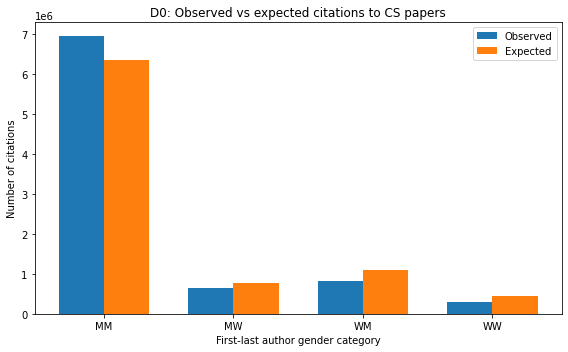

In [12]:
plot_data = baseline_d0_all_to_cs[['observed_citations', 'expected_citations']].copy()
x = np.arange(len(plot_data.index))
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, plot_data['observed_citations'], width, label='Observed')
plt.bar(x + width / 2, plot_data['expected_citations'], width, label='Expected')
plt.xticks(x, plot_data.index)
plt.xlabel('First-last author gender category')
plt.ylabel('Number of citations')
plt.title('D0: Observed vs expected citations to CS papers')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'baseline_d0_all_to_cs_observed_vs_expected.png', dpi=300)
plt.show()

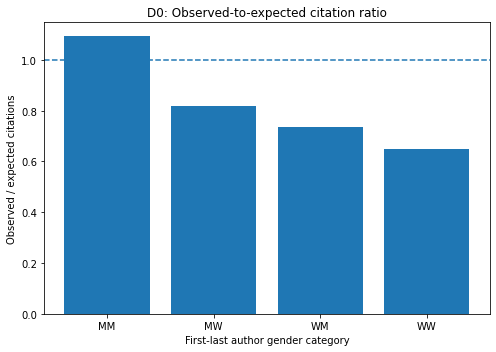

In [13]:
plot_data = baseline_d0_all_to_cs['obs_exp_ratio'].copy()
plt.figure(figsize=(7, 5))
plt.bar(plot_data.index, plot_data.values)
plt.axhline(1.0, linestyle='--')
plt.xlabel('First-last author gender category')
plt.ylabel('Observed / expected citations')
plt.title('D0: Observed-to-expected citation ratio')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'baseline_d0_all_to_cs_obs_exp_ratio.png', dpi=300)
plt.show()

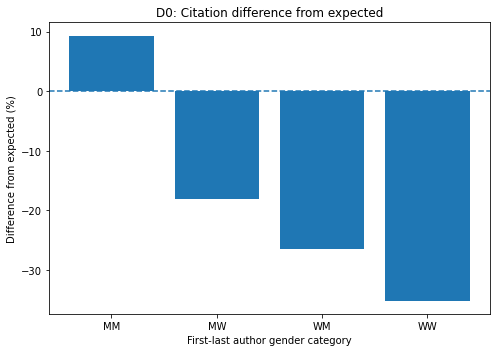

In [14]:
plot_data = baseline_d0_all_to_cs['difference_pct_of_expected'].copy()
plt.figure(figsize=(7, 5))
plt.bar(plot_data.index, plot_data.values)
plt.axhline(0.0, linestyle='--')
plt.xlabel('First-last author gender category')
plt.ylabel('Difference from expected (%)')
plt.title('D0: Citation difference from expected')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'baseline_d0_all_to_cs_difference_pct.png', dpi=300)
plt.show()

## 7. Robustness Slice: CS → Known-Gender CS Papers

In [15]:
baseline_d0_cs_to_cs = compute_global_paper_share_baseline(focal_papers=papers_cs_known, citation_edges=edges_cs_to_known_cs, known_categories=known_categories)
baseline_d0_cs_to_cs

,n_papers,paper_share,observed_citations,observed_share,expected_citations,expected_share,difference,difference_pct_of_expected,obs_exp_ratio
MM,790617,0.7311,5601920,0.7976,"5,135,092.0084",0.7311,"466,827.9916",9.0909,1.0909
MW,97399,0.0901,529022,0.0753,"632,610.7667",0.0901,"-103,588.7667",-16.3748,0.8363
WM,137756,0.1274,662200,0.0943,"894,731.2475",0.1274,"-232,531.2475",-25.9889,0.7401
WW,55591,0.0514,230358,0.0328,"361,065.9774",0.0514,"-130,707.9774",-36.2006,0.6380


In [16]:
baseline_d0_cs_to_cs_display = make_display_table(baseline_d0_cs_to_cs)
baseline_d0_cs_to_cs_display

,n_papers,paper_share,observed_citations,observed_share,expected_citations,expected_share,difference,difference_pct_of_expected,obs_exp_ratio
MM,790617,73.1100,5601920,79.7600,5135092,73.1100,466828,9.0900,1.0910
MW,97399,9.0100,529022,7.5300,632611,9.0100,-103589,-16.3700,0.8360
WM,137756,12.7400,662200,9.4300,894731,12.7400,-232531,-25.9900,0.7400
WW,55591,5.1400,230358,3.2800,361066,5.1400,-130708,-36.2000,0.6380


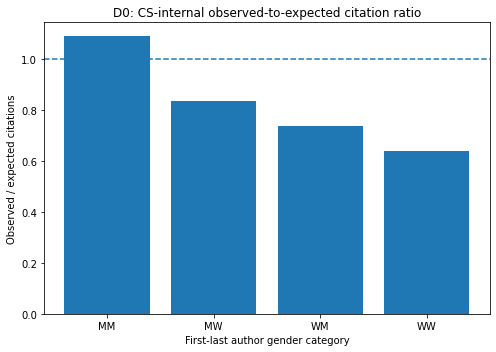

In [17]:
plot_data = baseline_d0_cs_to_cs['obs_exp_ratio'].copy()
plt.figure(figsize=(7, 5))
plt.bar(plot_data.index, plot_data.values)
plt.axhline(1.0, linestyle='--')
plt.xlabel('First-last author gender category')
plt.ylabel('Observed / expected citations')
plt.title('D0: CS-internal observed-to-expected citation ratio')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'baseline_d0_cs_to_cs_obs_exp_ratio.png', dpi=300)
plt.show()

## 8. Compare Main and Robustness Slices

In [18]:
d0_slice_comparison = pd.DataFrame({'all_to_cs_obs_exp_ratio': baseline_d0_all_to_cs['obs_exp_ratio'], 'cs_to_cs_obs_exp_ratio': baseline_d0_cs_to_cs['obs_exp_ratio'], 'all_to_cs_difference_pct_of_expected': baseline_d0_all_to_cs['difference_pct_of_expected'], 'cs_to_cs_difference_pct_of_expected': baseline_d0_cs_to_cs['difference_pct_of_expected']}).reindex(known_categories)
d0_slice_comparison = d0_slice_comparison.round(3)
d0_slice_comparison

,all_to_cs_obs_exp_ratio,cs_to_cs_obs_exp_ratio,all_to_cs_difference_pct_of_expected,cs_to_cs_difference_pct_of_expected
MM,1.0930,1.0910,9.3200,9.0910
MW,0.8200,0.8360,-18.0140,-16.3750
WM,0.7340,0.7400,-26.5710,-25.9890
WW,0.6490,0.6380,-35.1420,-36.2010


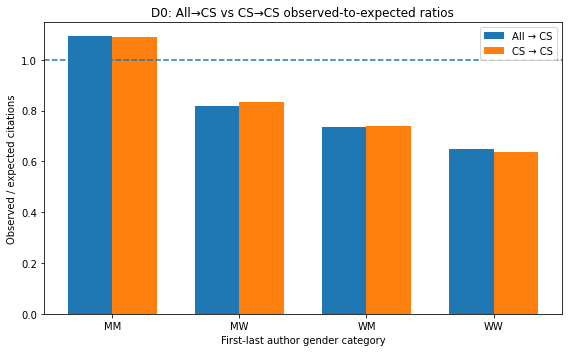

In [19]:
x = np.arange(len(known_categories))
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, d0_slice_comparison['all_to_cs_obs_exp_ratio'].reindex(known_categories), width, label='All → CS')
plt.bar(x + width / 2, d0_slice_comparison['cs_to_cs_obs_exp_ratio'].reindex(known_categories), width, label='CS → CS')
plt.axhline(1.0, linestyle='--')
plt.xticks(x, known_categories)
plt.xlabel('First-last author gender category')
plt.ylabel('Observed / expected citations')
plt.title('D0: All→CS vs CS→CS observed-to-expected ratios')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'baseline_d0_slice_comparison_obs_exp_ratio.png', dpi=300)
plt.show()

## 9. Save Outputs

In [20]:
cs_subset_summary.to_csv(TABLE_DIR / 'baseline_d0_cs_subset_summary.csv')
edge_slice_summary.to_csv(TABLE_DIR / 'baseline_d0_edge_slice_summary.csv')
baseline_d0_all_to_cs.to_csv(TABLE_DIR / 'baseline_d0_global_all_to_cs.csv')
baseline_d0_all_to_cs_display.to_csv(TABLE_DIR / 'baseline_d0_global_all_to_cs_display.csv')
baseline_d0_all_to_cs_with_paper_summary.to_csv(TABLE_DIR / 'baseline_d0_global_all_to_cs_with_paper_summary.csv')
baseline_d0_cs_to_cs.to_csv(TABLE_DIR / 'baseline_d0_global_cs_to_cs.csv')
baseline_d0_cs_to_cs_display.to_csv(TABLE_DIR / 'baseline_d0_global_cs_to_cs_display.csv')
cs_paper_level_summary.to_csv(TABLE_DIR / 'baseline_d0_cs_paper_level_summary.csv')
d0_slice_comparison.to_csv(TABLE_DIR / 'baseline_d0_global_slice_comparison.csv')
print('Saved D0 baseline tables to:', TABLE_DIR)

Saved D0 baseline tables to: c:\Users\blaze\OneDrive\Documents\GitHub\citation-gender-imbalance\outputs\06_baseline_d0_global_paper_share\tables
